# Website A/B Test Conversion Analysis

This project evaluates the effectiveness of a website redesign using an A/B testing experiment.

The goal is to determine whether the **new landing page (treatment)** leads to a higher conversion rate compared to the **existing landing page (control)**.

## Tools Used

- SQL (DuckDB)
- Python (Pandas, Statsmodels, Seaborn)
- Tableau

## Dataset

The dataset contains ~290k user interactions including:
- user_id
- timestamp
- experiment group (control or treatment)
- landing page version
- conversion outcome

The analysis includes SQL-based exploration, statistical significance testing, and visualization of experiment results.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

C:\Users\Arunita\anaconda31\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load Dataset

The dataset contains website experiment data where users were randomly assigned to either the control group (old page) or treatment group (new page).

In [2]:
df = pd.read_csv("../data/ab_data.csv")

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## Data Exploration

Check dataset size and structure.

In [3]:
df.shape

(294478, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


## Data Cleaning

### Remove mismatched records where the experiment group does not match the landing page version.

In [5]:
df = df[((df['group']=='control') & (df['landing_page']=='old_page')) |
        ((df['group']=='treatment') & (df['landing_page']=='new_page'))]

In [6]:
df.shape

(290585, 5)

### Remove duplicates

In [7]:
df.drop_duplicates(subset='user_id', inplace=True)

In [8]:
df.shape

(290584, 5)

## SQL-Based Analysis

We use DuckDB to run SQL queries directly on the dataset to analyze experiment traffic and conversion metrics.

### PULL data in SQL table

In [9]:
duckdb.sql("CREATE TABLE ab_test AS SELECT * FROM df")

### Experiment Traffic Distribution

Verify that the experiment traffic is evenly distributed between control and treatment groups.

In [10]:
query = """
SELECT
    "group",
    COUNT(*) AS users
FROM ab_test
GROUP BY "group"
"""

traffic_distribution = duckdb.sql(query).df()
traffic_distribution

,group,users
0,treatment,145310
1,control,145274


### Conversion Rate by Experiment Group

Calculate user count, total conversions, and conversion rate for control and treatment groups.

In [11]:
query = """
SELECT
    "group",
    COUNT(*) AS users,
    SUM(converted) AS conversions,
    ROUND(SUM(converted)*1.0/COUNT(*),4) AS conversion_rate
FROM ab_test
GROUP BY "group"
"""

conversion_rates = duckdb.sql(query).df()
conversion_rates

,group,users,conversions,conversion_rate
0,control,145274,17489.0,0.1204
1,treatment,145310,17264.0,0.1188


### Conversion Lift Analysis

To better understand the experiment impact, we calculate the relative conversion lift of the treatment group compared to the control group.

Conversion lift represents the percentage change in conversion rate between the treatment and control groups.                
A positive lift indicates improved performance from the new landing page, while a negative lift suggests worse performance.

In [12]:
control_rate = conversion_rates.loc[conversion_rates["group"]=="control","conversion_rate"].values[0]
treatment_rate = conversion_rates.loc[conversion_rates["group"]=="treatment","conversion_rate"].values[0]

lift = (treatment_rate - control_rate) / control_rate * 100

print(f"Conversion Lift: {lift:.2f}%")

Conversion Lift: -1.33%


### Daily Conversion Trend

Analyze how conversion rates change over time for both experiment groups.

In [13]:
query = """
SELECT
    DATE(timestamp) AS date,
    "group",
    AVG(converted) AS conversion_rate
FROM ab_test
GROUP BY date, "group"
ORDER BY date
"""

daily_trend = duckdb.sql(query).df()
daily_trend.head()

,date,group,conversion_rate
0,2017-01-02,treatment,0.119874
1,2017-01-02,control,0.125568
2,2017-01-03,control,0.113809
3,2017-01-03,treatment,0.113781
4,2017-01-04,control,0.121922


## Statistical Significance Testing

A two-proportion z-test is used to determine whether the difference in conversion rates between control and treatment groups is statistically significant.

In [14]:
control = df[df.group=="control"]["converted"]
treatment = df[df.group=="treatment"]["converted"]

conversions = [control.sum(), treatment.sum()]
n = [len(control), len(treatment)]

stat, pval = proportions_ztest(conversions, n)

print("P-value:", pval)

P-value: 0.18988337448195103


_If the p-value is less than 0.05, the difference between the two conversion rates is statistically significant._

## Confidence Interval for Conversion Difference

To further evaluate the experiment results, we compute a 95% confidence interval for the difference in conversion rates between the treatment and control groups.

In [15]:
p1 = control.mean()
p2 = treatment.mean()

n1 = len(control)
n2 = len(treatment)

se = np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))

diff = p2 - p1

ci_lower = diff - 1.96*se
ci_upper = diff + 1.96*se

print("95% Confidence Interval:", ci_lower, "to", ci_upper)

95% Confidence Interval: -0.003937903604443846 to 0.0007814256337327326


In [16]:
summary_chart = pd.DataFrame({
    "group": ["control","treatment"],
    "conversion_rate": [control_rate, treatment_rate],
    "sample_size": [len(control), len(treatment)]
})

summary_chart

,group,conversion_rate,sample_size
0,control,0.1204,145274
1,treatment,0.1188,145310


### Calculate Confidence Interval for Each Group

In [17]:
summary_chart["se"] = np.sqrt(
    summary_chart["conversion_rate"] *
    (1 - summary_chart["conversion_rate"]) /
    summary_chart["sample_size"]
)

summary_chart["ci_lower"] = summary_chart["conversion_rate"] - 1.96*summary_chart["se"]
summary_chart["ci_upper"] = summary_chart["conversion_rate"] + 1.96*summary_chart["se"]

summary_chart

,group,conversion_rate,sample_size,se,ci_lower,ci_upper
0,control,0.1204,145274,0.000854,0.118727,0.122073
1,treatment,0.1188,145310,0.000849,0.117136,0.120464


## Visualization of Experiment Results

### Conversion Rate Comparison

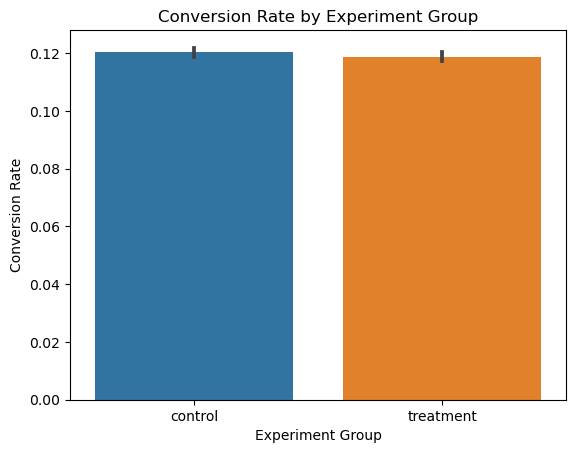

In [18]:
sns.barplot(data=df, x="group", y="converted")

plt.title("Conversion Rate by Experiment Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Experiment Group")

plt.show()

### Daily Conversion Trend

C:\Users\Arunita\anaconda31\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Arunita\anaconda31\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Arunita\anaconda31\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Arunita\anaconda31\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to p

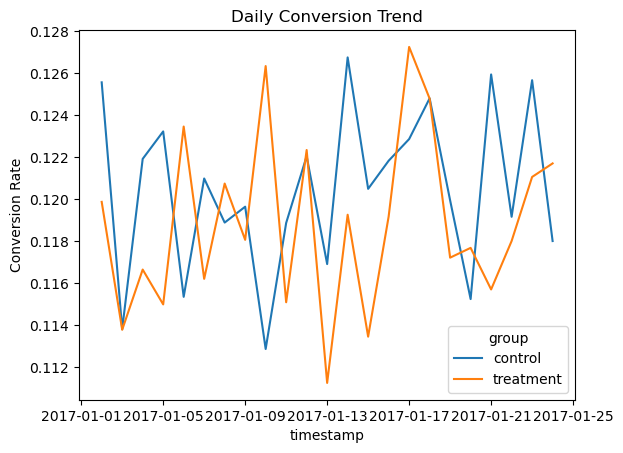

In [19]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

daily = df.groupby([df['timestamp'].dt.date,'group'])['converted'].mean().reset_index()

sns.lineplot(data=daily, x='timestamp', y='converted', hue='group')

plt.title("Daily Conversion Trend")
plt.ylabel("Conversion Rate")

plt.show()

## Conversion Rate Comparison with Confidence Intervals

This visualization compares conversion rates between the control and treatment groups.

Error bars represent the 95% confidence interval for each group, helping assess whether the difference in performance is meaningful.

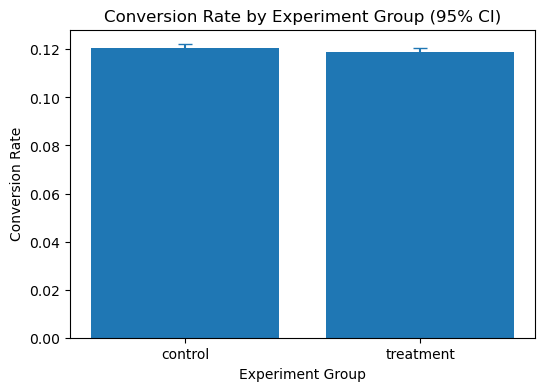

In [20]:
plt.figure(figsize=(6,4))

plt.bar(summary_chart["group"], summary_chart["conversion_rate"])

plt.errorbar(
    summary_chart["group"],
    summary_chart["conversion_rate"],
    yerr=1.96*summary_chart["se"],
    fmt='none',
    capsize=5
)

plt.title("Conversion Rate by Experiment Group (95% CI)")
plt.ylabel("Conversion Rate")
plt.xlabel("Experiment Group")

plt.show()

## Experiment Summary

The following table summarizes the key experiment results including conversion rates, lift, and statistical significance.

In [21]:
summary = pd.DataFrame({
    "Metric":[
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Conversion Lift (%)",
        "P-value"
    ],
    "Value":[
        round(control_rate,4),
        round(treatment_rate,4),
        round(lift,2),
        pval
    ]
})

summary

,Metric,Value
0,Control Conversion Rate,0.120400
1,Treatment Conversion Rate,0.118800
2,Conversion Lift (%),-1.330000
3,P-value,0.189883


## Export Aggregated Data for Tableau Dashboard

In [22]:
daily.to_csv("../tableau_dashboard/daily_conversion.csv", index=False)
conversion_rates.to_csv("../tableau_dashboard/conversion_rates.csv", index=False)

## Key Findings

- The experiment included approximately **290k user interactions**.
- Traffic distribution between control and treatment groups was balanced.
- Conversion rates between the two landing pages were very similar.
- Statistical testing indicates that the difference in conversion rates is **not statistically significant**.
- Based on the analysis, the new landing page does not meaningfully improve user conversion performance.

## Potential Next Steps

- Conduct further experimentation with alternative landing page designs.
- Analyze user behavior by device type or geographic region.
- Evaluate additional engagement metrics beyond conversions.